In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

retail = pd.read_csv("../data/raw/retail_price.csv")

print("Shape:", retail.shape)
print("\nColumns:")
print(retail.columns.tolist())

retail.head()

Shape: (676, 30)

Columns:
['product_id', 'product_category_name', 'month_year', 'qty', 'total_price', 'freight_price', 'unit_price', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_score', 'customers', 'weekday', 'weekend', 'holiday', 'month', 'year', 's', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2', 'comp_3', 'ps3', 'fp3', 'lag_price']


,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed1,bed_bath_table,01-05-2017,1,45.95,15.100000,45.95,39,161,2,...,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90
1,bed1,bed_bath_table,01-06-2017,3,137.85,12.933333,45.95,39,161,2,...,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95
2,bed1,bed_bath_table,01-07-2017,6,275.70,14.840000,45.95,39,161,2,...,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95
3,bed1,bed_bath_table,01-08-2017,4,183.80,14.287500,45.95,39,161,2,...,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95
4,bed1,bed_bath_table,01-09-2017,2,91.90,15.100000,45.95,39,161,2,...,89.9,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95


In [2]:
retail["month_year"] = pd.to_datetime(
    retail["month_year"],
    dayfirst=True
)

print(retail["month_year"].min())
print(retail["month_year"].max())

2017-01-01 00:00:00
2018-08-01 00:00:00


In [3]:
retail["Month"] = retail["month_year"].dt.month
retail["Year"] = retail["month_year"].dt.year

retail["Quarter"] = retail["month_year"].dt.quarter

retail["Is_First_Half"] = retail["Month"] <= 6
retail["Is_Second_Half"] = retail["Month"] >= 7

In [4]:
retail["Avg_Competitor_Price"] = retail[
    ["comp_1", "comp_2", "comp_3"]
].mean(axis=1)

retail["Min_Competitor_Price"] = retail[
    ["comp_1", "comp_2", "comp_3"]
].min(axis=1)

retail["Max_Competitor_Price"] = retail[
    ["comp_1", "comp_2", "comp_3"]
].max(axis=1)

In [5]:
retail["Price_Difference"] = (
    retail["unit_price"] - retail["Avg_Competitor_Price"]
)

retail["Price_Gap_Pct"] = (
    (retail["unit_price"] - retail["Avg_Competitor_Price"])
    / retail["Avg_Competitor_Price"]
) * 100

In [6]:
retail["Price_Change"] = (
    retail["unit_price"] - retail["lag_price"]
)

retail["Price_Change_Pct"] = (
    (retail["unit_price"] - retail["lag_price"])
    / retail["lag_price"]
) * 100

In [7]:
print("Shape:", retail.shape)

print("\nNew columns:")
print(retail.columns.tolist())

display(
    retail[
        [
            "product_id",
            "month_year",
            "qty",
            "unit_price",
            "lag_price",
            "Avg_Competitor_Price",
            "Price_Difference",
            "Price_Gap_Pct",
            "Price_Change",
            "Price_Change_Pct"
        ]
    ].head(10)
)

Shape: (676, 42)

New columns:
['product_id', 'product_category_name', 'month_year', 'qty', 'total_price', 'freight_price', 'unit_price', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_score', 'customers', 'weekday', 'weekend', 'holiday', 'month', 'year', 's', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2', 'comp_3', 'ps3', 'fp3', 'lag_price', 'Month', 'Year', 'Quarter', 'Is_First_Half', 'Is_Second_Half', 'Avg_Competitor_Price', 'Min_Competitor_Price', 'Max_Competitor_Price', 'Price_Difference', 'Price_Gap_Pct', 'Price_Change', 'Price_Change_Pct']


,product_id,month_year,qty,unit_price,lag_price,Avg_Competitor_Price,Price_Difference,Price_Gap_Pct,Price_Change,Price_Change_Pct
0,bed1,2017-05-01,1,45.950000,45.900000,116.950000,-71.000000,-60.709705,0.050000,0.108932
1,bed1,2017-06-01,3,45.950000,45.950000,114.950000,-69.000000,-60.026098,0.000000,0.000000
2,bed1,2017-07-01,6,45.950000,45.950000,113.616667,-67.666667,-59.556990,0.000000,0.000000
3,bed1,2017-08-01,4,45.950000,45.950000,111.786601,-65.836601,-58.894895,0.000000,0.000000
4,bed1,2017-09-01,2,45.950000,45.950000,99.749570,-53.799570,-53.934638,0.000000,0.000000
5,bed1,2017-10-01,3,45.950000,45.950000,60.600000,-14.650000,-24.174917,0.000000,0.000000
6,bed1,2017-11-01,11,40.531818,45.950000,56.987879,-16.456061,-28.876422,-5.418182,-11.791473
7,bed1,2017-12-01,6,39.990000,40.531818,56.156078,-16.166078,-28.787762,-0.541818,-1.336772
8,bed1,2018-01-01,19,39.990000,39.990000,55.626667,-15.636667,-28.110019,0.000000,0.000000
9,bed1,2018-02-01,18,39.990000,39.990000,55.626667,-15.636667,-28.110019,0.000000,0.000000


In [8]:
# Price and demand correlation

price_demand_corr = retail[
    ["unit_price", "qty", "Price_Change_Pct", "Price_Gap_Pct"]
].corr()

print("Price-Demand Correlation Matrix:")
display(price_demand_corr)

Price-Demand Correlation Matrix:


,unit_price,qty,Price_Change_Pct,Price_Gap_Pct
unit_price,1.000000,-0.103432,-0.022981,0.764214
qty,-0.103432,1.000000,-0.175789,-0.077115
Price_Change_Pct,-0.022981,-0.175789,1.000000,0.017168
Price_Gap_Pct,0.764214,-0.077115,0.017168,1.000000


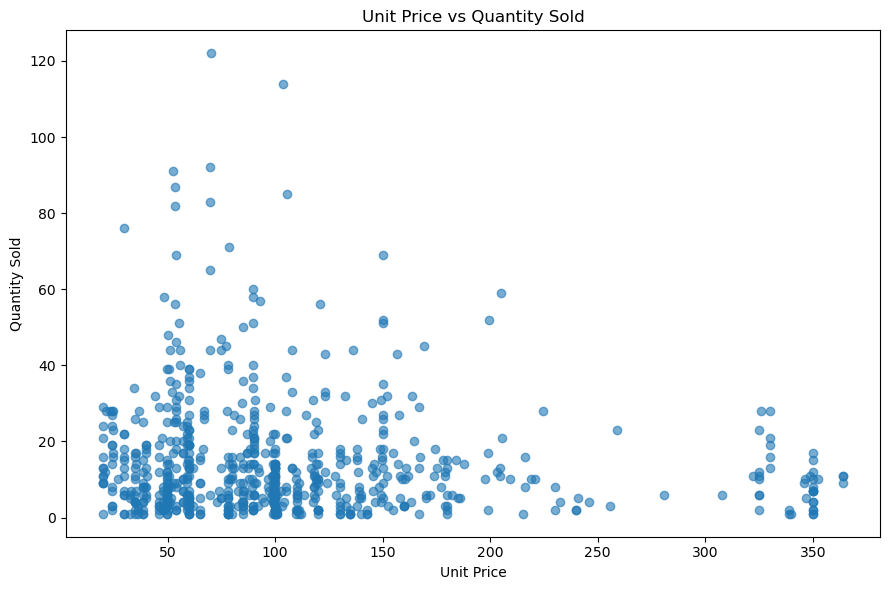

In [9]:
# Price vs Quantity

plt.figure(figsize=(9, 6))

plt.scatter(
    retail["unit_price"],
    retail["qty"],
    alpha=0.6
)

plt.xlabel("Unit Price")
plt.ylabel("Quantity Sold")
plt.title("Unit Price vs Quantity Sold")

plt.tight_layout()
plt.show()

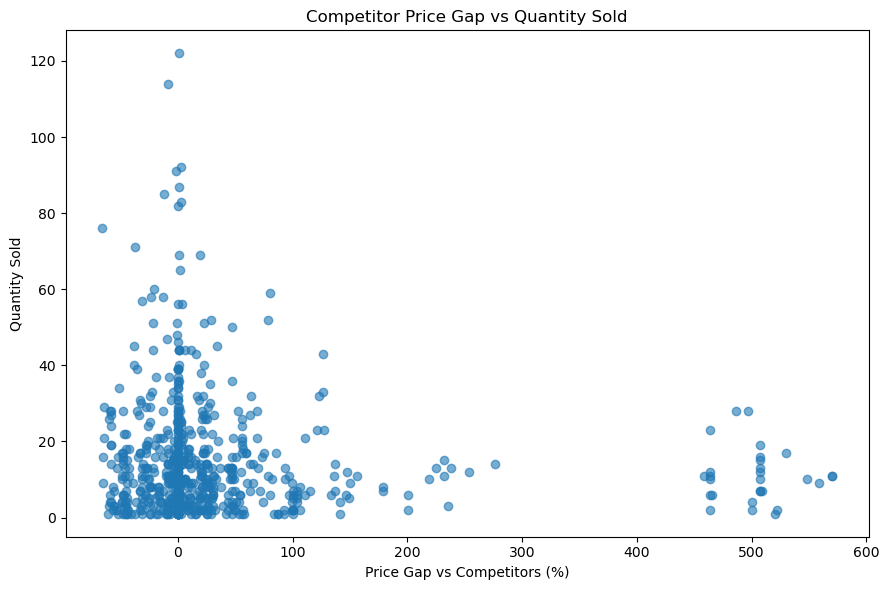

In [10]:
# Competitor price gap vs demand

plt.figure(figsize=(9, 6))

plt.scatter(
    retail["Price_Gap_Pct"],
    retail["qty"],
    alpha=0.6
)

plt.xlabel("Price Gap vs Competitors (%)")
plt.ylabel("Quantity Sold")
plt.title("Competitor Price Gap vs Quantity Sold")

plt.tight_layout()
plt.show()

In [11]:
# Step 7: Calculate Price Elasticity

retail = retail.sort_values(["product_id", "month_year"])

# Percentage change in quantity for each product
retail["Qty_Change_Pct"] = (
    retail.groupby("product_id")["qty"]
    .pct_change() * 100
)

# Price elasticity of demand
retail["Price_Elasticity"] = (
    retail["Qty_Change_Pct"] / retail["Price_Change_Pct"]
)

print("Price Elasticity calculated.")
display(
    retail[
        [
            "product_id",
            "month_year",
            "unit_price",
            "qty",
            "Price_Change_Pct",
            "Qty_Change_Pct",
            "Price_Elasticity"
        ]
    ].head(15)
)

Price Elasticity calculated.


,product_id,month_year,unit_price,qty,Price_Change_Pct,Qty_Change_Pct,Price_Elasticity
0,bed1,2017-05-01,45.950000,1,0.108932,NaN,NaN
1,bed1,2017-06-01,45.950000,3,0.000000,200.000000,inf
2,bed1,2017-07-01,45.950000,6,0.000000,100.000000,inf
3,bed1,2017-08-01,45.950000,4,0.000000,-33.333333,-inf
4,bed1,2017-09-01,45.950000,2,0.000000,-50.000000,-inf
5,bed1,2017-10-01,45.950000,3,0.000000,50.000000,inf
6,bed1,2017-11-01,40.531818,11,-11.791473,266.666667,-22.615213
7,bed1,2017-12-01,39.990000,6,-1.336772,-45.454545,34.003203
8,bed1,2018-01-01,39.990000,19,0.000000,216.666667,inf
9,bed1,2018-02-01,39.990000,18,0.000000,-5.263158,-inf


In [12]:
# Step 7B: Keep only valid price-change observations

elasticity_data = retail[
    (retail["Price_Change_Pct"] != 0) &
    (retail["Price_Change_Pct"].notna()) &
    (retail["Qty_Change_Pct"].notna())
].copy()

# Remove infinite elasticity values
elasticity_data = elasticity_data[
    np.isfinite(elasticity_data["Price_Elasticity"])
]

print("Valid elasticity observations:", len(elasticity_data))

display(
    elasticity_data[
        [
            "product_id",
            "month_year",
            "unit_price",
            "qty",
            "Price_Change_Pct",
            "Qty_Change_Pct",
            "Price_Elasticity"
        ]
    ].head(20)
)

Valid elasticity observations: 312


,product_id,month_year,unit_price,qty,Price_Change_Pct,Qty_Change_Pct,Price_Elasticity
6,bed1,2017-11-01,40.531818,11,-11.791473,266.666667,-22.615213
7,bed1,2017-12-01,39.990000,6,-1.336772,-45.454545,34.003203
15,bed1,2018-08-01,39.240000,8,-1.875469,0.000000,-0.000000
448,bed2,2017-12-01,88.488235,18,-1.570372,-55.000000,35.023542
449,bed2,2018-01-01,86.900000,17,-1.794855,-5.555556,3.095267
452,bed2,2018-04-01,85.045000,6,-2.134638,-64.705882,30.312351
453,bed2,2018-05-01,83.649615,26,-1.640760,333.333333,-203.157846
454,bed2,2018-06-01,79.900000,23,-4.482526,-11.538462,2.574098
455,bed2,2018-07-01,77.933333,10,-2.461410,-56.521739,22.963154
456,bed2,2018-08-01,74.000000,7,-5.047049,-30.000000,5.944068


In [13]:
# Step 8: Product-level Price Elasticity Summary

product_elasticity = (
    elasticity_data
    .groupby("product_id")["Price_Elasticity"]
    .agg(
        Elasticity_Observations="count",
        Mean_Elasticity="mean",
        Median_Elasticity="median",
        Min_Elasticity="min",
        Max_Elasticity="max"
    )
    .reset_index()
)

print("Product-level elasticity summary:")
print("Number of products:", product_elasticity["product_id"].nunique())

display(product_elasticity)

Product-level elasticity summary:
Number of products: 51


,product_id,Elasticity_Observations,Mean_Elasticity,Median_Elasticity,Min_Elasticity,Max_Elasticity
0,bed1,3,3.795997,-0.000000,-22.615213,34.003203
1,bed2,7,-14.749338,5.944068,-203.157846,35.023542
2,bed3,5,-53.273727,-19.159814,-163.555556,-0.000000
3,bed4,3,-10.001602,-11.475000,-15.809596,-2.720209
4,bed5,4,-142.992489,-126.950021,-322.500000,4.430085
5,computers1,10,-70.933761,-9.137466,-354.649773,7.908333
6,computers2,7,17.482436,8.060606,-21.101730,117.600633
7,computers3,8,184.393781,0.875257,-201.128049,1773.333333
8,computers4,14,-86.391941,-2.022552,-1279.520000,34.808572
9,computers5,6,168.525919,-3.082880,-1257.900000,2397.000000


In [14]:
# Step 9: Classify products based on median price elasticity

product_elasticity["Abs_Median_Elasticity"] = (
    product_elasticity["Median_Elasticity"].abs()
)

def classify_elasticity(value):
    if value < 1:
        return "Inelastic"
    elif value > 1:
        return "Elastic"
    else:
        return "Unit Elastic"

product_elasticity["Elasticity_Type"] = (
    product_elasticity["Abs_Median_Elasticity"]
    .apply(classify_elasticity)
)

# Add a reliability indicator based on number of observations
def reliability_level(n):
    if n >= 8:
        return "Higher"
    elif n >= 4:
        return "Moderate"
    else:
        return "Lower"

product_elasticity["Reliability"] = (
    product_elasticity["Elasticity_Observations"]
    .apply(reliability_level)
)

display(
    product_elasticity[
        [
            "product_id",
            "Elasticity_Observations",
            "Median_Elasticity",
            "Abs_Median_Elasticity",
            "Elasticity_Type",
            "Reliability"
        ]
    ].sort_values("Median_Elasticity")
)

,product_id,Elasticity_Observations,Median_Elasticity,Abs_Median_Elasticity,Elasticity_Type,Reliability
32,health1,1,-849.400000,849.400000,Elastic,Lower
10,computers6,1,-706.666293,706.666293,Elastic,Lower
15,cool3,4,-230.225877,230.225877,Elastic,Moderate
4,bed5,4,-126.950021,126.950021,Elastic,Moderate
38,health7,3,-36.749702,36.749702,Elastic,Lower
20,furniture3,5,-32.680222,32.680222,Elastic,Moderate
2,bed3,5,-19.159814,19.159814,Elastic,Moderate
48,watches6,13,-17.347660,17.347660,Elastic,Higher
3,bed4,3,-11.475000,11.475000,Elastic,Lower
33,health10,6,-10.437332,10.437332,Elastic,Moderate


In [15]:
# Step 10: Overall elasticity summary

print("Total valid elasticity observations:", len(elasticity_data))

print("\nMedian elasticity across all valid observations:",
      elasticity_data["Price_Elasticity"].median())

print("Mean elasticity across all valid observations:",
      elasticity_data["Price_Elasticity"].mean())

print("\nElasticity statistics:")
display(
    elasticity_data["Price_Elasticity"].describe()
)

Total valid elasticity observations: 312

Median elasticity across all valid observations: -3.0358392808370827
Mean elasticity across all valid observations: 266.7560685796407

Elasticity statistics:


count      312.000000
mean       266.756069
std       3205.295518
min      -8842.508843
25%        -17.318119
50%         -3.035839
75%          8.278393
max      44175.000000
Name: Price_Elasticity, dtype: float64

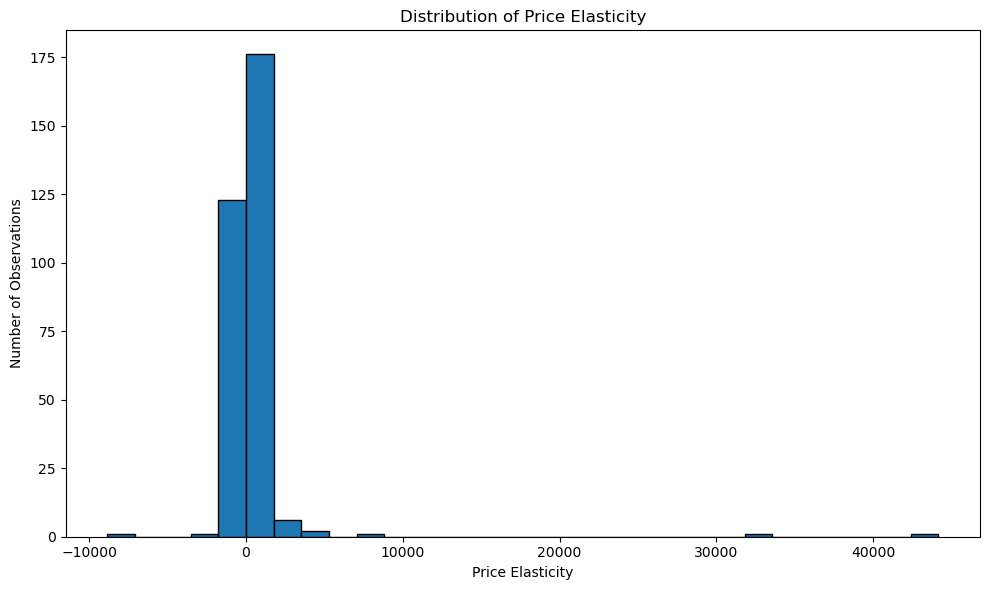

In [16]:
# Elasticity distribution

plt.figure(figsize=(10, 6))

plt.hist(
    elasticity_data["Price_Elasticity"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Price Elasticity")
plt.ylabel("Number of Observations")
plt.title("Distribution of Price Elasticity")

plt.tight_layout()
plt.show()

In [17]:
# Step 11: Competitor Price Position

def classify_price_position(gap):
    if gap < -5:
        return "Below Competitors"
    elif gap > 5:
        return "Above Competitors"
    else:
        return "Similar to Competitors"

retail["Competitive_Position"] = (
    retail["Price_Gap_Pct"]
    .apply(classify_price_position)
)

print("Competitive price position distribution:")

display(
    retail["Competitive_Position"]
    .value_counts()
    .to_frame("Number_of_Records")
)

Competitive price position distribution:


,Number_of_Records
Competitive_Position,
Above Competitors,283
Similar to Competitors,200
Below Competitors,193


In [18]:
# Average quantity by competitive position

competitive_summary = (
    retail.groupby("Competitive_Position")
    .agg(
        Average_Quantity=("qty", "mean"),
        Median_Quantity=("qty", "median"),
        Average_Unit_Price=("unit_price", "mean"),
        Average_Price_Gap_Pct=("Price_Gap_Pct", "mean")
    )
    .reset_index()
)

display(competitive_summary)

,Competitive_Position,Average_Quantity,Median_Quantity,Average_Unit_Price,Average_Price_Gap_Pct
0,Above Competitors,12.462898,10.0,154.796462,99.604289
1,Below Competitors,14.901554,11.0,65.569570,-30.584428
2,Similar to Competitors,16.980000,11.0,77.647554,0.185097


In [19]:
# Step 12: Final Feature Engineering Quality Check

print("Dataset shape:", retail.shape)

print("\nNew engineered columns:")
new_columns = [
    "Month",
    "Year",
    "Quarter",
    "Is_First_Half",
    "Is_Second_Half",
    "Avg_Competitor_Price",
    "Min_Competitor_Price",
    "Max_Competitor_Price",
    "Price_Difference",
    "Price_Gap_Pct",
    "Price_Change",
    "Price_Change_Pct",
    "Qty_Change_Pct",
    "Price_Elasticity",
    "Competitive_Position"
]

display(retail[new_columns].head())

print("\nMissing values in engineered columns:")
display(retail[new_columns].isnull().sum())

print("\nInfinite values in Price Elasticity:")
print(
    np.isinf(retail["Price_Elasticity"]).sum()
)

Dataset shape: (676, 45)

New engineered columns:


,Month,Year,Quarter,Is_First_Half,Is_Second_Half,Avg_Competitor_Price,Min_Competitor_Price,Max_Competitor_Price,Price_Difference,Price_Gap_Pct,Price_Change,Price_Change_Pct,Qty_Change_Pct,Price_Elasticity,Competitive_Position
0,5,2017,2,True,False,116.950000,45.95,215.000000,-71.000000,-60.709705,0.05,0.108932,NaN,NaN,Below Competitors
1,6,2017,2,True,False,114.950000,45.95,209.000000,-69.000000,-60.026098,0.00,0.000000,200.000000,inf,Below Competitors
2,7,2017,3,False,True,113.616667,45.95,205.000000,-67.666667,-59.556990,0.00,0.000000,100.000000,inf,Below Competitors
3,8,2017,3,False,True,111.786601,45.95,199.509804,-65.836601,-58.894895,0.00,0.000000,-33.333333,-inf,Below Competitors
4,9,2017,3,False,True,99.749570,45.95,163.398710,-53.799570,-53.934638,0.00,0.000000,-50.000000,-inf,Below Competitors



Missing values in engineered columns:


Month                    0
Year                     0
Quarter                  0
Is_First_Half            0
Is_Second_Half           0
Avg_Competitor_Price     0
Min_Competitor_Price     0
Max_Competitor_Price     0
Price_Difference         0
Price_Gap_Pct            0
Price_Change             0
Price_Change_Pct         0
Qty_Change_Pct          52
Price_Elasticity        81
Competitive_Position     0
dtype: int64


Infinite values in Price Elasticity:
283


In [20]:
# Step 13: Finalize Pricing Features and Save

# Replace infinite elasticity values with NaN
retail["Price_Elasticity"] = retail["Price_Elasticity"].replace(
    [np.inf, -np.inf],
    np.nan
)

# Save complete engineered pricing dataset
retail.to_csv(
    "../data/processed/retail_price_features.csv",
    index=False
)

# Save product-level elasticity summary
product_elasticity.to_csv(
    "../data/processed/product_elasticity_summary.csv",
    index=False
)

print("Pricing feature engineering completed successfully.")
print()
print("Pricing features shape:", retail.shape)
print("Product elasticity summary shape:", product_elasticity.shape)
print()
print("Files saved:")
print("1. ../data/processed/retail_price_features.csv")
print("2. ../data/processed/product_elasticity_summary.csv")

Pricing feature engineering completed successfully.

Pricing features shape: (676, 45)
Product elasticity summary shape: (51, 9)

Files saved:
1. ../data/processed/retail_price_features.csv
2. ../data/processed/product_elasticity_summary.csv


In [21]:
import shutil
import os

source = "../data/processed/next_month_demand_predictions.csv"
destination = "../data/predictions/next_month_demand_predictions.csv"

if os.path.exists(source):
    shutil.copy2(source, destination)
    print("✓ next_month_demand_predictions.csv copied successfully")
else:
    print("❌ Source file not found")s

✓ next_month_demand_predictions.csv copied successfully
